In [20]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
from src.data_models.caravanify import Caravanify, CaravanifyConfig


# Step 1: Extract Anthropogenic Attributes

A good source for anthropogenic attributes is the following link: https://data.hydrosheds.org/file/technical-documentation/BasinATLAS_Catalog_v10.pdf   


In [31]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)
# Load the static attributes for all gauges

caravan = Caravanify(config)
ids_for_training = caravan.get_all_gauge_ids()[:100]
caravan.load_stations(ids_for_training)
static_data = caravan.get_static_attributes()

# Identify anthropogenic attributes in the dataset
anthro_columns = [
    "ppd_pk_sav",  # Population density
    "urb_pc_sse",  # Urban extent
    "rdd_mk_sav",  # Road density
    "nli_ix_sav",  # Nighttime lights
    "gdp_ud_sav",  # GDP
    "hdi_ix_sav",  # Human development index
    "dor_pc_pva",  #  Degree or regulation
    "rev_mc_usu",  # Reservoir volume
]

# Check which attributes are actually present in the dataset
available_anthro = [col for col in anthro_columns if col in static_data.columns]
print(f"Available anthropogenic attributes: {available_anthro}")

# Create subset with only anthropogenic attributes and gauge_id
anthro_data = static_data[["gauge_id"] + available_anthro].copy()
print("\nAnthropogenic attributes data:")
print(anthro_data.head())

Available anthropogenic attributes: ['ppd_pk_sav', 'urb_pc_sse', 'rdd_mk_sav', 'nli_ix_sav', 'gdp_ud_sav', 'hdi_ix_sav', 'dor_pc_pva', 'rev_mc_usu']

Anthropogenic attributes data:
  gauge_id  ppd_pk_sav  urb_pc_sse   rdd_mk_sav   nli_ix_sav    gdp_ud_sav  \
0  CH_2009  105.199830    8.446419   751.665744  1870.322985  44065.279041   
1  CH_2011   72.906975    5.683587   529.042694  1460.594310  43170.830324   
2  CH_2016  421.659411   33.398608  2921.137724  4307.785803  49331.450653   
3  CH_2018  516.148783   42.328410  3320.327415  4670.428820  62643.039717   
4  CH_2019   13.474564    0.021423   246.021452   370.757023  49477.426883   

   hdi_ix_sav  dor_pc_pva  rev_mc_usu  
0  943.170662         216        1107  
1  938.306233         165         649  
2  939.000000          84         667  
3  939.000000          24         101  
4  938.998868         254         203  


# Step 2: Handle Missing Values

In [23]:
# Check for missing values
missing_values = anthro_data.isna().sum()
print("Missing values per attribute:")
print(missing_values)

# Impute missing values with median
for col in available_anthro:
   if anthro_data[col].isna().any():
       median_val = anthro_data[col].median()
       anthro_data[col].fillna(median_val, inplace=True)

print("\nAfter imputation - missing values:")
print(anthro_data.isna().sum())

Missing values per attribute:
gauge_id      0
ppd_pk_sav    0
urb_pc_sse    0
rdd_mk_sav    0
nli_ix_sav    0
gdp_ud_sav    0
hdi_ix_sav    0
dor_pc_pva    0
rev_mc_usu    0
dtype: int64

After imputation - missing values:
gauge_id      0
ppd_pk_sav    0
urb_pc_sse    0
rdd_mk_sav    0
nli_ix_sav    0
gdp_ud_sav    0
hdi_ix_sav    0
dor_pc_pva    0
rev_mc_usu    0
dtype: int64


# Step 3: Normalize Attributes


In [24]:

# Initialize the scaler
scaler = MinMaxScaler()

# Fit and transform the data (excluding gauge_id)
norm_data = pd.DataFrame(
   scaler.fit_transform(anthro_data[available_anthro]),
   columns=available_anthro
)

# Add gauge_id back to normalized data
norm_data['gauge_id'] = anthro_data['gauge_id'].values

print("Normalized anthropogenic attributes:")
print(norm_data.head())

Normalized anthropogenic attributes:
   ppd_pk_sav  urb_pc_sse  rdd_mk_sav  nli_ix_sav  gdp_ud_sav  hdi_ix_sav  \
0    0.079940    0.127205    0.150097    0.292606    0.189810    1.000000   
1    0.054184    0.085596    0.098209    0.217113    0.162748    0.900972   
2    0.332341    0.502992    0.655748    0.741709    0.349139    0.915096   
3    0.407703    0.637477    0.748789    0.808526    0.751884    0.915096   
4    0.006782    0.000323    0.032243    0.016310    0.353556    0.915073   

   dor_pc_pva  rev_mc_usu gauge_id  
0    0.263736    0.647747  CH_2009  
1    0.201465    0.379754  CH_2011  
2    0.102564    0.390287  CH_2016  
3    0.029304    0.059099  CH_2018  
4    0.310134    0.118783  CH_2019  


# Step 4: Define weights and calculate Human Influence Index (HII)


In [25]:
# weights = {attr: 1/len(available_anthro) for attr in available_anthro}
# print("Weights assigned to each attribute:")
# print(weights)

# anthro_columns = [
#     "ppd_pk_sav",  # Population density
#     "urb_pc_sse",  # Urban extent
#     "rdd_mk_sav",  # Road density
#     "nli_ix_sav",  # Nighttime lights
#     "hf_ix_s93",  # Human footprint 1993
#     "hf_ix_s09",  # Human footprint 2009
#     "gdp_ud_sav",  # GDP
#     "hdi_ix_sav",  # Human development index
#     "dor_pc_pva",  #  Degree or regulation
#     "rev_mc_usu",  # Reservoir volume
# ]

weights_raw = {'ppd_pk_sav':1, 'urb_pc_sse':1, 'rdd_mk_sav':1, 'nli_ix_sav':1, 'gdp_ud_sav':3, 'hdi_ix_sav':1, 'dor_pc_pva':5, 'rev_mc_usu':5}

weights = {attr: 1/len(available_anthro) for attr in available_anthro}
for attr in available_anthro:
    if attr in weights_raw:
        weights[attr] = weights_raw[attr] / sum(weights_raw.values())
    else:
        weights[attr] = 0


assert sum(weights.values()) == 1, "Weights should sum up to 1"

print("Weights assigned to each attribute:")
print(weights)



Weights assigned to each attribute:
{'ppd_pk_sav': 0.05555555555555555, 'urb_pc_sse': 0.05555555555555555, 'rdd_mk_sav': 0.05555555555555555, 'nli_ix_sav': 0.05555555555555555, 'gdp_ud_sav': 0.16666666666666666, 'hdi_ix_sav': 0.05555555555555555, 'dor_pc_pva': 0.2777777777777778, 'rev_mc_usu': 0.2777777777777778}


In [26]:
available_anthro

['ppd_pk_sav',
 'urb_pc_sse',
 'rdd_mk_sav',
 'nli_ix_sav',
 'gdp_ud_sav',
 'hdi_ix_sav',
 'dor_pc_pva',
 'rev_mc_usu']

In [27]:
# Calculate HII (weighted sum of normalized attributes)
hii_values = np.zeros(len(norm_data))

for attr in available_anthro:
   hii_values += weights[attr] * norm_data[attr].values

# Add HII to the normalized data
norm_data['hii'] = hii_values / np.max(hii_values)

print("\nData with HII scores:")
print(norm_data[['gauge_id', 'hii']].head())


Data with HII scores:
  gauge_id       hii
0  CH_2009  0.693115
1  CH_2011  0.485869
2  CH_2016  0.681134
3  CH_2018  0.635691
4  CH_2019  0.427116


# Step 5: Categorize catchments based on HII



Count of catchments in each category:
human_influence_category
High      60
Medium    30
Low       10
Name: count, dtype: int64

Final classification with original values:
  gauge_id       hii human_influence_category  ppd_pk_sav  urb_pc_sse  \
0  CH_2009  0.693115                     High  105.199830    8.446419   
1  CH_2011  0.485869                     High   72.906975    5.683587   
2  CH_2016  0.681134                     High  421.659411   33.398608   
3  CH_2018  0.635691                     High  516.148783   42.328410   
4  CH_2019  0.427116                     High   13.474564    0.021423   

    rdd_mk_sav   nli_ix_sav    gdp_ud_sav  hdi_ix_sav  dor_pc_pva  rev_mc_usu  
0   751.665744  1870.322985  44065.279041  943.170662         216        1107  
1   529.042694  1460.594310  43170.830324  938.306233         165         649  
2  2921.137724  4307.785803  49331.450653  939.000000          84         667  
3  3320.327415  4670.428820  62643.039717  939.000000          24   

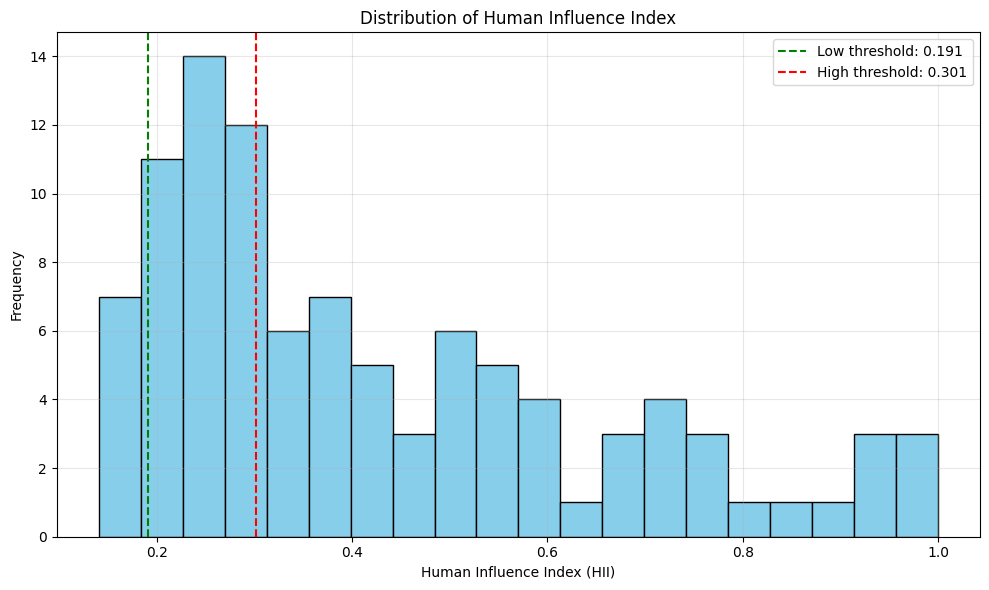

In [28]:
# Define thresholds for categories (using tertiles)
low_threshold = np.percentile(hii_values, 50)
high_threshold = np.percentile(hii_values, 75)

# Assign categories
def assign_category(hii):
   if hii < low_threshold:
       return "Low"
   elif hii < high_threshold:
       return "Medium"
   else:
       return "High"

norm_data['human_influence_category'] = norm_data['hii'].apply(assign_category)

# Count catchments in each category
category_counts = norm_data['human_influence_category'].value_counts()
print("\nCount of catchments in each category:")
print(category_counts)

# Add original attributes to the output
result_df = pd.merge(
   norm_data[['gauge_id', 'hii', 'human_influence_category']],
   anthro_data,
   on='gauge_id'
)

print("\nFinal classification with original values:")
print(result_df.head())

basin_count = len(ids_for_training)
number_of_bins = int(np.ceil(2 * basin_count ** (1/3)))


plt.figure(figsize=(10, 6))
plt.hist(norm_data['hii'], bins=20, color='skyblue', edgecolor='black')
plt.axvline(low_threshold, color='green', linestyle='--', label=f'Low threshold: {low_threshold:.3f}')
plt.axvline(high_threshold, color='red', linestyle='--', label=f'High threshold: {high_threshold:.3f}')
plt.xlabel('Human Influence Index (HII)')
plt.ylabel('Frequency')
plt.title('Distribution of Human Influence Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 6: Plot streamflow data for examples from each category


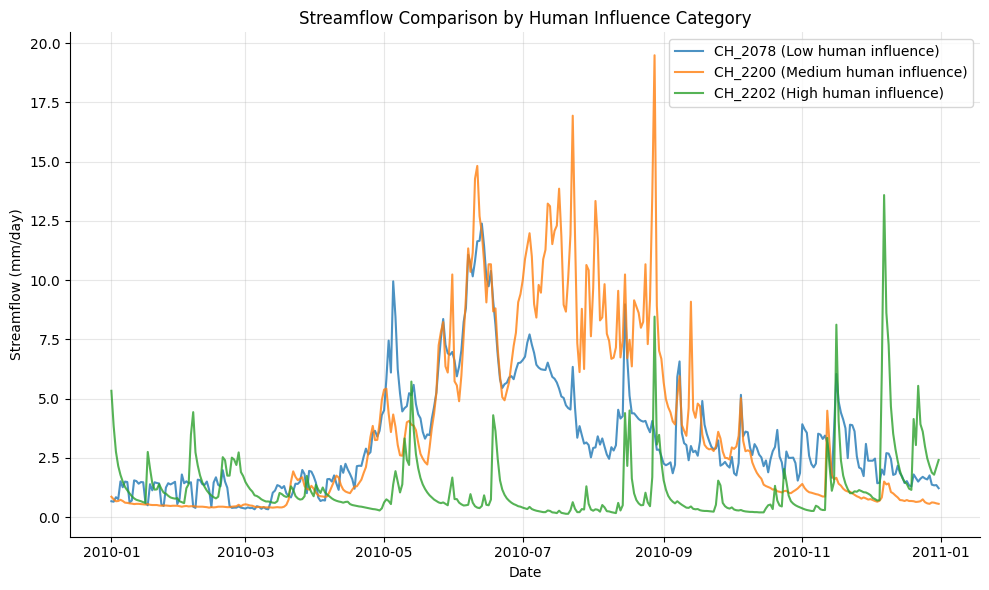


Comparison of human influence metrics:


,gauge_id,human_influence_category,hii,ppd_pk_sav,urb_pc_sse,rdd_mk_sav,nli_ix_sav,gdp_ud_sav,hdi_ix_sav,dor_pc_pva,rev_mc_usu
15,CH_2078,Low,0.149202,23.352217,0.944284,249.869929,805.299270,45060.644779,925.516273,0,0
48,CH_2200,Medium,0.226717,23.051262,0.268033,174.130336,789.492610,50727.652176,939.000000,0,0
49,CH_2202,High,0.940716,290.836921,23.179608,2380.363884,2839.699835,52909.435811,939.426884,53,1709


In [29]:
# Get one example from each category
example_gauges = {}
for category in ["Low", "Medium", "High"]:
    # Randomly select a gauge_id for each category
    category_gauges = result_df[result_df["human_influence_category"] == category][
        "gauge_id"
    ].values
    if len(category_gauges) > 0:
        example_gauges[category] = np.random.choice(category_gauges)
    else:
        print(f"No catchments in {category} category")

# Plot streamflow time series for each example
plt.figure(figsize=(10, 6))

all_ts_data = caravan.get_time_series()

for category, gauge_id in example_gauges.items():
    ts_data = all_ts_data[all_ts_data["gauge_id"] == gauge_id]

    # Keep only data from 2000 to 2001
    ts_data = ts_data[
        (ts_data["date"] >= "2010-01-01") & (ts_data["date"] <= "2010-12-31")
    ]

    if len(ts_data) > 0 and "streamflow" in ts_data.columns:
        # Convert date to datetime if needed
        if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
            ts_data["date"] = pd.to_datetime(ts_data["date"])

        # Plot streamflow
        plt.plot(
            ts_data["date"],
            ts_data["streamflow"],
            label=f"{gauge_id} ({category} human influence)",
            alpha=0.8,
        )
    else:
        print(f"No streamflow data available for {gauge_id}")

plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title("Streamflow Comparison by Human Influence Category")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()

# Create a table with human influence metrics for the examples
comparison_df = result_df[result_df["gauge_id"].isin(example_gauges.values())]
print("\nComparison of human influence metrics:")
display(
    comparison_df[["gauge_id", "human_influence_category", "hii"] + available_anthro]
)


Data for basin CH_2239:


,gauge_id,hii,human_influence_category,ppd_pk_sav,urb_pc_sse,rdd_mk_sav,nli_ix_sav,gdp_ud_sav,hdi_ix_sav,dor_pc_pva,rev_mc_usu
54,CH_2239,0.551358,High,21.959318,0.027499,221.689062,1246.777552,43579.622726,918.976959,599,165


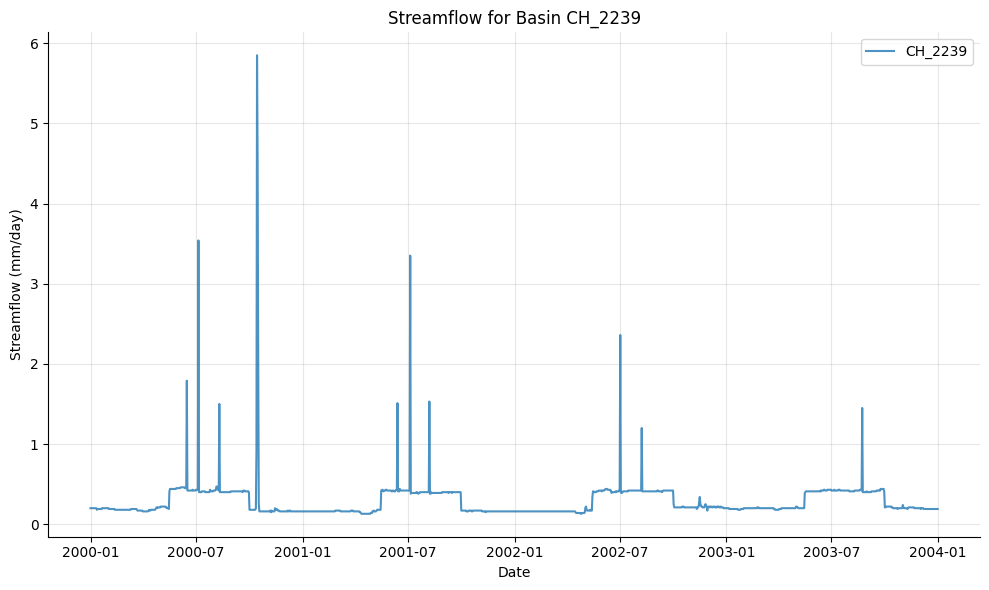

In [30]:
# Find basin CH_2239
basin_id = "CH_2239"
if basin_id in result_df["gauge_id"].values:
    basin_data = result_df[result_df["gauge_id"] == basin_id]
    print(f"\nData for basin {basin_id}:")
    display(basin_data)
else:
    print(f"Basin {basin_id} not found in the dataset.")

# Plot streamflow time series for basin CH_2239
plt.figure(figsize=(10, 6))
ts_data = all_ts_data[all_ts_data["gauge_id"] == basin_id]
ts_data = ts_data[
    (ts_data["date"] >= "2000-01-01") & (ts_data["date"] <= "2003-12-31")
]
if len(ts_data) > 0 and "streamflow" in ts_data.columns:
    if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
        ts_data["date"] = pd.to_datetime(ts_data["date"])

    plt.plot(
        ts_data["date"],
        ts_data["streamflow"],
        label=f"{basin_id}",
        alpha=0.8,
    )
else:
    print(f"No streamflow data available for {basin_id}")
plt.xlabel("Date")
plt.ylabel("Streamflow (mm/day)")
plt.title(f"Streamflow for Basin {basin_id}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()